In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

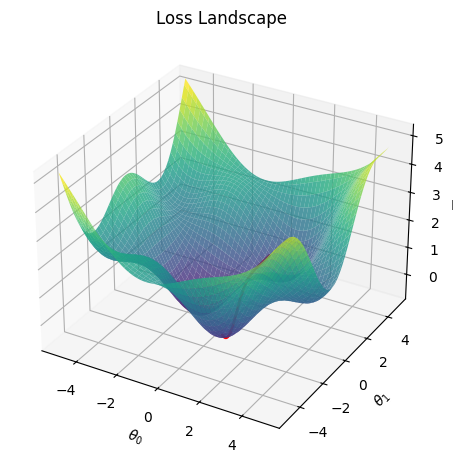

In [2]:
# Define the loss function with multiple local minima
def loss_function(theta0, theta1):
    return np.sin(theta0) * np.cos(theta1) + 0.1 * (theta0**2 + theta1**2)

# Gradient descent function to simulate trajectory
def gradient_descent(initial_theta, learning_rate, iterations):
    theta_history = [initial_theta]
    theta = np.array(initial_theta)

    for _ in range(iterations):
        # Compute gradients of the updated loss function
        grad = np.array([
            np.cos(theta[0]) * np.cos(theta[1]) + 0.2 * theta[0],  # Gradient w.r.t. theta0
            -np.sin(theta[0]) * np.sin(theta[1]) + 0.2 * theta[1]  # Gradient w.r.t. theta1
        ])

        # Update theta based on the gradient
        theta -= learning_rate * grad
        theta_history.append(theta.copy())

    return np.array(theta_history)

# Generate grid for theta0 and theta1
theta0_vals = np.linspace(-5, 5, 100)
theta1_vals = np.linspace(-5, 5, 100)
theta0, theta1 = np.meshgrid(theta0_vals, theta1_vals)

# Calculate the loss function values on the grid
loss_vals = loss_function(theta0, theta1)

# Perform gradient descent from an initial point
initial_theta = [4.5, -4.5]
learning_rate = 0.1
iterations = 100
theta_history = gradient_descent(initial_theta, learning_rate, iterations)

# 3D Plot of the loss landscape
fig = plt.figure(figsize=(12, 6))

# 3D loss landscape plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(theta0, theta1, loss_vals, cmap='viridis', alpha=0.8)
ax1.set_title("Loss Landscape")
ax1.set_xlabel(r'$\theta_0$')
ax1.set_ylabel(r'$\theta_1$')
ax1.set_zlabel('Loss')

# Overlay gradient descent trajectory
ax1.plot(theta_history[:, 0], theta_history[:, 1], loss_function(theta_history[:, 0], theta_history[:, 1]), 'r-', lw=2)

plt.show()


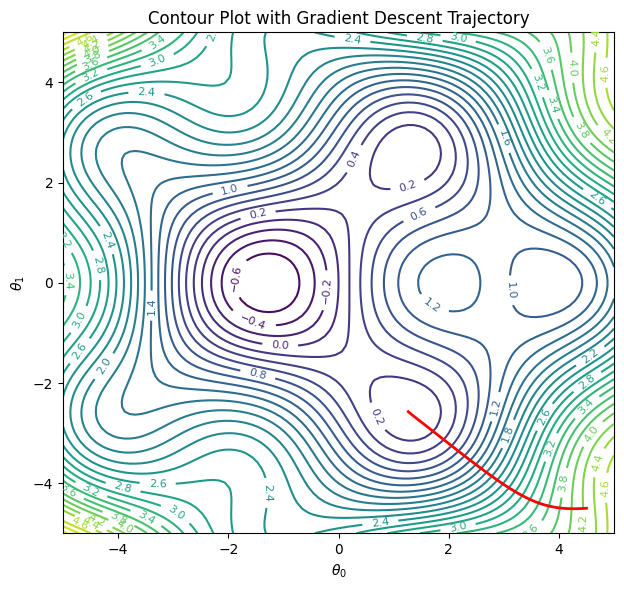

In [3]:
# 3D Plot of the loss landscape
fig = plt.figure(figsize=(12, 6))

# 2D Contour plot
ax2 = fig.add_subplot(121)
contour = ax2.contour(theta0, theta1, loss_vals, levels=30, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_title("Contour Plot with Gradient Descent Trajectory")
ax2.set_xlabel(r'$\theta_0$')
ax2.set_ylabel(r'$\theta_1$')

# Overlay gradient descent trajectory
ax2.plot(theta_history[:, 0], theta_history[:, 1], 'r-', lw=2)

plt.tight_layout()

plt.show()

## Interactive Controls\nUse the widget panel below to explore parameters live inside JupyterLite.\n

In [ ]:
# INTERACTIVE_WIDGET_SECTION\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport ipywidgets as widgets\n\ndef _interactive_demo(freq=1.0, amp=1.0, phase=0.0):\n    x=np.linspace(-10,10,500)\n    y=amp*np.sin(freq*x+phase)\n    plt.figure(figsize=(8,4))\n    plt.plot(x,y,lw=2)\n    plt.grid(True)\n    plt.title('Interactive Demo Panel')\n    plt.show()\n\nwidgets.interact(_interactive_demo,\n    freq=widgets.FloatSlider(value=1.0,min=0.1,max=5.0,step=0.1),\n    amp=widgets.FloatSlider(value=1.0,min=0.1,max=3.0,step=0.1),\n    phase=widgets.FloatSlider(value=0.0,min=-3.14,max=3.14,step=0.1))\n